In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import contextily as cx
import seaborn as sns
import shapely

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.cluster import HDBSCAN

from transformers import TrackCellTransformer

In [3]:
df_tracks = gpd.read_parquet("../data/cleaned/track_info.parquet")
df_tracks['start_point'].iloc[0].coords[0]

(-88.321538, 41.911011)

In [4]:

    
# class PointCellTransformer(TransformerMixin, BaseEstimator):
#     def __init__(self, cell_res=11):
#         self.cell_res = cell_res

#     def fit(self, X, y=None):
#         return self

#     def transform(self, X):
#         return X.iloc[:, 0].apply(lambda point: h3.latlng_to_cell(point.coords[0][0], point.coords[0][1], res=self.cell_res)).to_frame()
    
# start_cell_pipeline = Pipeline(
#     steps=[
#         ('h3', PointCellTransformer(cell_res=6)),
#         ('encoder', OneHotEncoder()),
#         ('weight', FunctionTransformer((lambda x: 10*x))),
#     ]
# )

# num_pipeline = Pipeline(
#     steps=[
#         ('scaler', StandardScaler())
#     ]
# )


In [ ]:
cell_res = 11
min_cluster_size = 4

track_cells_pipeline = Pipeline(
    steps=[
        ('h3', TrackCellTransformer(cell_res=cell_res)),
        ('vectorizor', TfidfVectorizer()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('track_line_cells', track_cells_pipeline, ["track_line"]),
    ],
    remainder='drop'
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('estimator', HDBSCAN(metric='cosine', min_cluster_size=min_cluster_size)),
    ]
)

In [6]:
_ = model.fit(df_tracks)

/Users/ryansponzilli/Developer/Python Projects/xc-routes/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [7]:
df_tracks['route_label'] = model.named_steps['estimator'].labels_
df_tracks['route_probability'] = model.named_steps['estimator'].probabilities_

* multipage_plots_0: resolution 12 with numeric parameters
    * OK, but missing some routes
* multipage_plots_1: resolution 12 without numeric parameters
    * Markedly better
* multipage_plots_2: resolution 12 without numeric parameters, with start point cell resolution 6
    * Markedly worse than both

In [8]:
num_groups = len(df_tracks['route_label'].value_counts())
mean_group_size = df_tracks['route_label'].loc[df_tracks['route_label'] != -1].value_counts().mean()
median_group_size = df_tracks['route_label'].loc[df_tracks['route_label'] != -1].value_counts().median()
num_runs_without_group = len(df_tracks.loc[df_tracks['route_label'] == -1])
print(num_groups, num_runs_without_group)
print(mean_group_size, median_group_size)

69 271
11.205882352941176 7.5


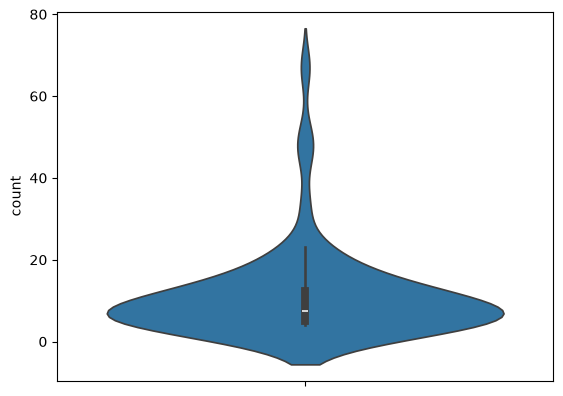

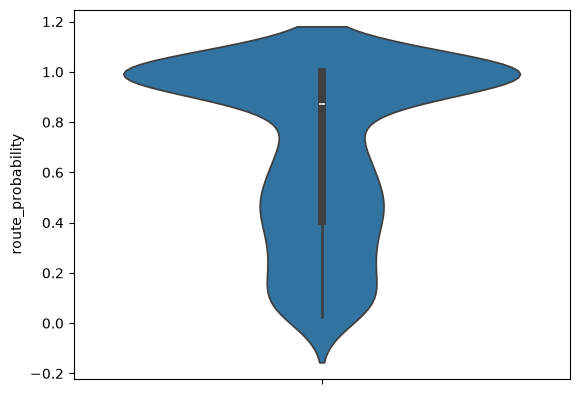

In [9]:
sns.violinplot(df_tracks['route_label'].loc[df_tracks['route_label'] != -1].value_counts())
plt.show()
sns.violinplot(df_tracks['route_probability'].loc[df_tracks['route_label'] != -1])
plt.show()

In [96]:
with PdfPages('multipage_plots.pdf') as pdf:

    ### TITLE PAGE
    page_num = 1
    num_groups = len(df_tracks['route_label'].value_counts())
    num_runs_without_group = len(df_tracks.loc[df_tracks['route_label'] == -1])
    mean_group_size = df_tracks['route_label'].loc[df_tracks['route_label'] != -1].value_counts().mean()
    median_group_size = df_tracks['route_label'].loc[df_tracks['route_label'] != -1].value_counts().median()

    fig_cover = plt.figure(figsize=(8.5, 11))
    plt.axis('off')
    
    # Add centered text using Figure coordinates (0,0 is bottom-left, 1,1 is top-right)
    plt.text(0.5, 0.9, 'Unsupervised Route Clustering Results', transform=fig_cover.transFigure, size=24, ha='center', weight='bold')
    plt.text(0.5, 0.85, 'Generated automatically via Matplotlib', transform=fig_cover.transFigure, size=14, ha='center', style='italic')
    plt.text(0.5, 0.77, f'Number of Runs: {len(df_tracks)}', transform=fig_cover.transFigure, size=10, ha='center')
    plt.text(0.5, 0.75, f'Number of Clusters: {num_groups}', transform=fig_cover.transFigure, size=10, ha='center')
    plt.text(0.5, 0.73, f'Unclustered Routes: {num_runs_without_group}', transform=fig_cover.transFigure, size=10, ha='center')
    plt.text(0.5, 0.71, f'Mean Cluster Size: {mean_group_size:.2f}', transform=fig_cover.transFigure, size=10, ha='center')
    plt.text(0.5, 0.69, f'Median Cluster Size: {median_group_size}', transform=fig_cover.transFigure, size=10, ha='center')
    plt.text(0.2, 0.50, model, transform=fig_cover.transFigure, size=10)

    # Save Page
    plt.text(0.025, 0.97, page_num, transform=fig_cover.transFigure)
    pdf.savefig(fig_cover)
    plt.close(fig_cover)
    page_num += 1


    ### TABLE OF CONTENTS
    fig_toc = plt.figure(figsize=(8.5, 11))
    plt.axis('off')
    toc_items = np.cumsum(df_tracks.loc[df_tracks['route_label'] != -1]['route_label'].value_counts().sort_index()  // 6 + 2) + 1
    for i, (route_id, page_num) in enumerate(list(zip(toc_items.index, toc_items.values))):
        plt.text(0.4, 0.95-i*0.013, f"Page {page_num} Cluster {route_id}", transform=fig_toc.transFigure, size=7)
    # Save Page
    page_num = 2
    plt.text(0.025, 0.97, page_num, transform=fig_toc.transFigure)
    pdf.savefig(fig_toc)
    plt.close(fig_toc)
    page_num  = 3

    ### BODY
    for i, (name, group) in enumerate(df_tracks.groupby("route_label")):
        if name == -1:
            continue

        fig, ax = plt.subplots(figsize=(8.5, 11))
        group.to_crs(3857).plot("route_probability", ax=ax, legend=True, cmap='RdBu')
        cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)
        ax.tick_params(bottom=False, top=False, left=False, right=False, labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        fig.text(0.025, 0.97, page_num)
        fig.text(0.025, 0.93, f"N={len(group)}", transform=fig.transFigure, fontsize=10, fontweight='bold')
        fig.text(0.025, 0.91, f"Mean Prob:{group['route_probability'].mean():.2f}", transform=fig.transFigure, fontsize=10, fontweight='bold')
        fig.text(0.025, 0.89, f"Median Prob:{group['route_probability'].median():.2f}", transform=fig.transFigure, fontsize=10, fontweight='bold')
        fig.text(0.025, 0.87, f"Min Prob:{group['route_probability'].min():.2f}", transform=fig.transFigure, fontsize=10, fontweight='bold')
        fig.text(0.35, 0.95, f"Cluster {name}", transform=fig.transFigure, fontsize=28, fontweight='bold')
        page_num += 1
        pdf.savefig(fig)
        plt.close(fig)

        # make a new page every 6 routes in the group
        run_num = 0
        row = 0
        col = 0
        for j in range((len(group) // 6) + 1*(len(group) % 6 != 0)):
            fig, ax = plt.subplots(3, 2, figsize=(8.5, 11))
            for k in range(min(len(group) - (j*6), 6)):
                group[run_num:run_num+1].to_crs(3857).plot(ax=ax[row, col])
                cx.add_basemap(ax[row, col], source=cx.providers.CartoDB.Voyager)
                # ax[row, col].set_title(group[run_num:run_num+1].iloc[0]['track_file_datetime'])
                ax[row, col].text(0.2, 1.1, group[run_num:run_num+1].iloc[0]['track_file_datetime'], transform=ax[row, col].transAxes)
                ax[row, col].tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
                if row < 2:
                    row += 1
                else:
                    row = 0
                    col += 1
                run_num += 1
            col = 0
            row = 0
            fig.text(0.01, 0.97, page_num)
            page_num += 1
            pdf.savefig(fig)
            plt.close(fig)

/Users/ryansponzilli/Developer/Python Projects/xc-routes/.venv/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 21 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)
/Users/ryansponzilli/Developer/Python Projects/xc-routes/.venv/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 21 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


In [10]:
df_tracks.loc[df_tracks['track_file_datetime'] == "2019-09-26 15:34:00-05:00"]

,track_file,track_file_datetime,track_file_date,start_datetime,end_datetime,year,season,total_duration,total_distance (mi),average_pace (min/mi),total_elevation_change (m),in_stc,start_point,end_point,track_line,route_label,route_probability
109,/Users/ryansponzilli/Developer/Python Projects...,2019-09-26 15:34:00-05:00,2019-09-26,2019-09-26 20:31:57+00:00,2019-09-26 20:34:36+00:00,Freshman,XC Season,0 days 00:02:39,0.23832,7.54246,2.363862,True,POINT (-88.27736 41.92831),POINT (-88.27728 41.92826),"MULTILINESTRING ((-88.27736 41.92831, -88.2773...",58,1.0
